# I-ROCKET Demo: GunPoint Dataset (UCR Archive)

This notebook demonstrates the complete I-ROCKET analysis workflow on the
GunPoint dataset from the UCR Time Series Classification Archive. GunPoint
is a two-class problem: subjects either draw a gun from a hip holster or
simply point their finger. The time series are centroid-y coordinates of
the right hand extracted from video, with 150 timepoints per trial.

GunPoint is a useful test case because the class-discriminative signal is
a smooth, distributed shape difference (the hand trajectory differs during
the draw/return phase) rather than a localized spike. This contrasts with
the three bumps synthetic dataset and illustrates how I-ROCKET's
interpretability tools behave on real experimental data.

**Please note that the aeon package is required for this demonstration
notebook. You can install aeon following these instructions:**
- https://www.aeon-toolkit.org/en/stable/installation.html

## 0. Setup

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

RANDOM_STATE = 42

## 1. Load and visualize the data

The GunPoint dataset is loaded from the UCR archive via aeon. The two
classes are labeled "Draw" (class 0) and "Point" (class 1). Individual
trials are plotted in light color with the class mean overlaid. The key
difference is visible around timepoints 60–100, where the gun-draw
trajectory dips lower than the point trajectory.

In [2]:
import numpy as np
from aeon.datasets import load_classification

X, y = load_classification("GunPoint")
X = np.squeeze(X)
y = np.where(y=='1', 0, 1)
print("Shape of X = ", X.shape)

Shape of X =  (200, 150)


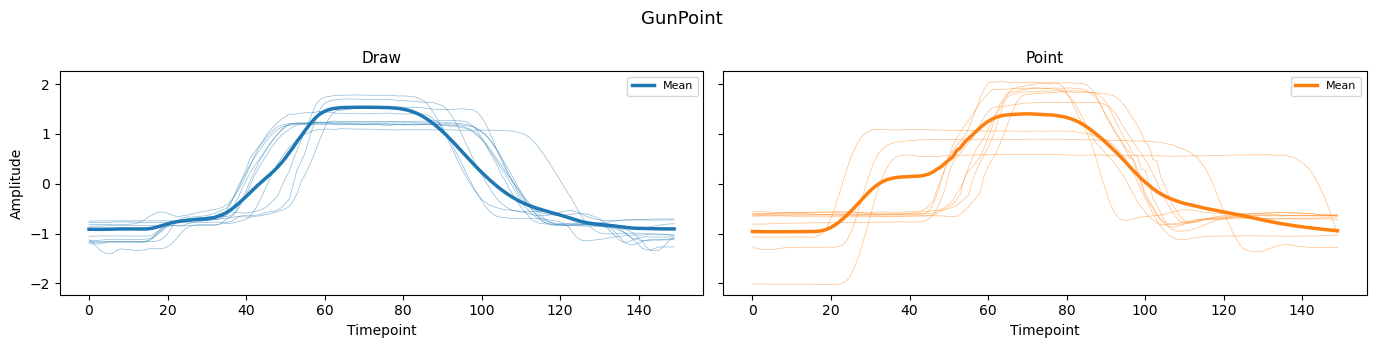

In [3]:
import matplotlib.pyplot as plt

# Plot class-mean signals with individual trial examples
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
class_names = ["Draw", "Point"]
colors = ["tab:blue", "tab:orange"]

for k in range(2):
    ax = axes[k]
    mask = y == k
    # Plot a few individual trials
    for i in np.where(mask)[0][:10]:
        ax.plot(X[i], color=colors[k], alpha=0.5, linewidth=0.5)
    # Plot class mean
    ax.plot(X[mask].mean(axis=0), color=colors[k], linewidth=2.5, label="Mean")
    ax.set_title(class_names[k], fontsize=11)
    ax.set_xlabel("Timepoint")
    if k == 0:
        ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8)

fig.suptitle(f"GunPoint", fontsize=13)
plt.tight_layout()

## 2. Cross-Validated Model

In [4]:
import interp_rocket as IR

results = IR.cross_validate(
    X, y,
    n_repeats=5,
    n_folds=5,
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)

print(f"\n5x5 Cross-validation results:")
for metric in ['accuracy', 'balanced_accuracy', 'mcc']:
    m = results[metric]
    print(f"  {metric:>20s}: {m['mean']:.4f} +/- {m['std']:.4f}")

Cross-validation: 5 repeats × 5 folds = 25 evaluations
  Data: 200 instances × 150 timepoints, 2 classes
  Class counts: {np.int64(0): 100, np.int64(1): 100}
  Repeat  1/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  2/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  3/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  4/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000
  Repeat  5/5: acc = 1.0000  bal_acc = 1.0000  mcc = 1.0000

  Results (mean ± std across 25 folds):
    accuracy            : 1.0000 ± 0.0000
    balanced_accuracy   : 1.0000 ± 0.0000
    f1_macro            : 1.0000 ± 0.0000
    f1_weighted         : 1.0000 ± 0.0000
    mcc                 : 1.0000 ± 0.0000
    mutual_info         : 1.0000 ± 0.0000

  Aggregated confusion matrix:
            0       1
     0     500       0
     1       0     500

5x5 Cross-validation results:
              accuracy: 1.0000 +/- 0.0000
     balanced_accuracy: 1.0000 +/- 0.0000
                   mcc: 1.0000 +/-

## 3. Visualization of the full model

### Fit a model with all data for the purposes of interpretability

In [5]:
# Fit a reference model on all data for stability analysis
model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)
model.fit(X, y)

InterpRocket.fit: 200 instances × 150 timepoints
  Classes: [0 1]
  Fitting dilations (raw)...
  Fitting biases (raw): 3108 biases across 5 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 3108 biases across 5 dilations...
  Transforming training data...
  Feature matrix: (200, 24864)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 0.0000


,max_dilations_per_kernel,16
,num_features,10000
,random_state,42
,alpha_range,array([1.0000...00000000e+10])
,class_weight,None


### Top kernels

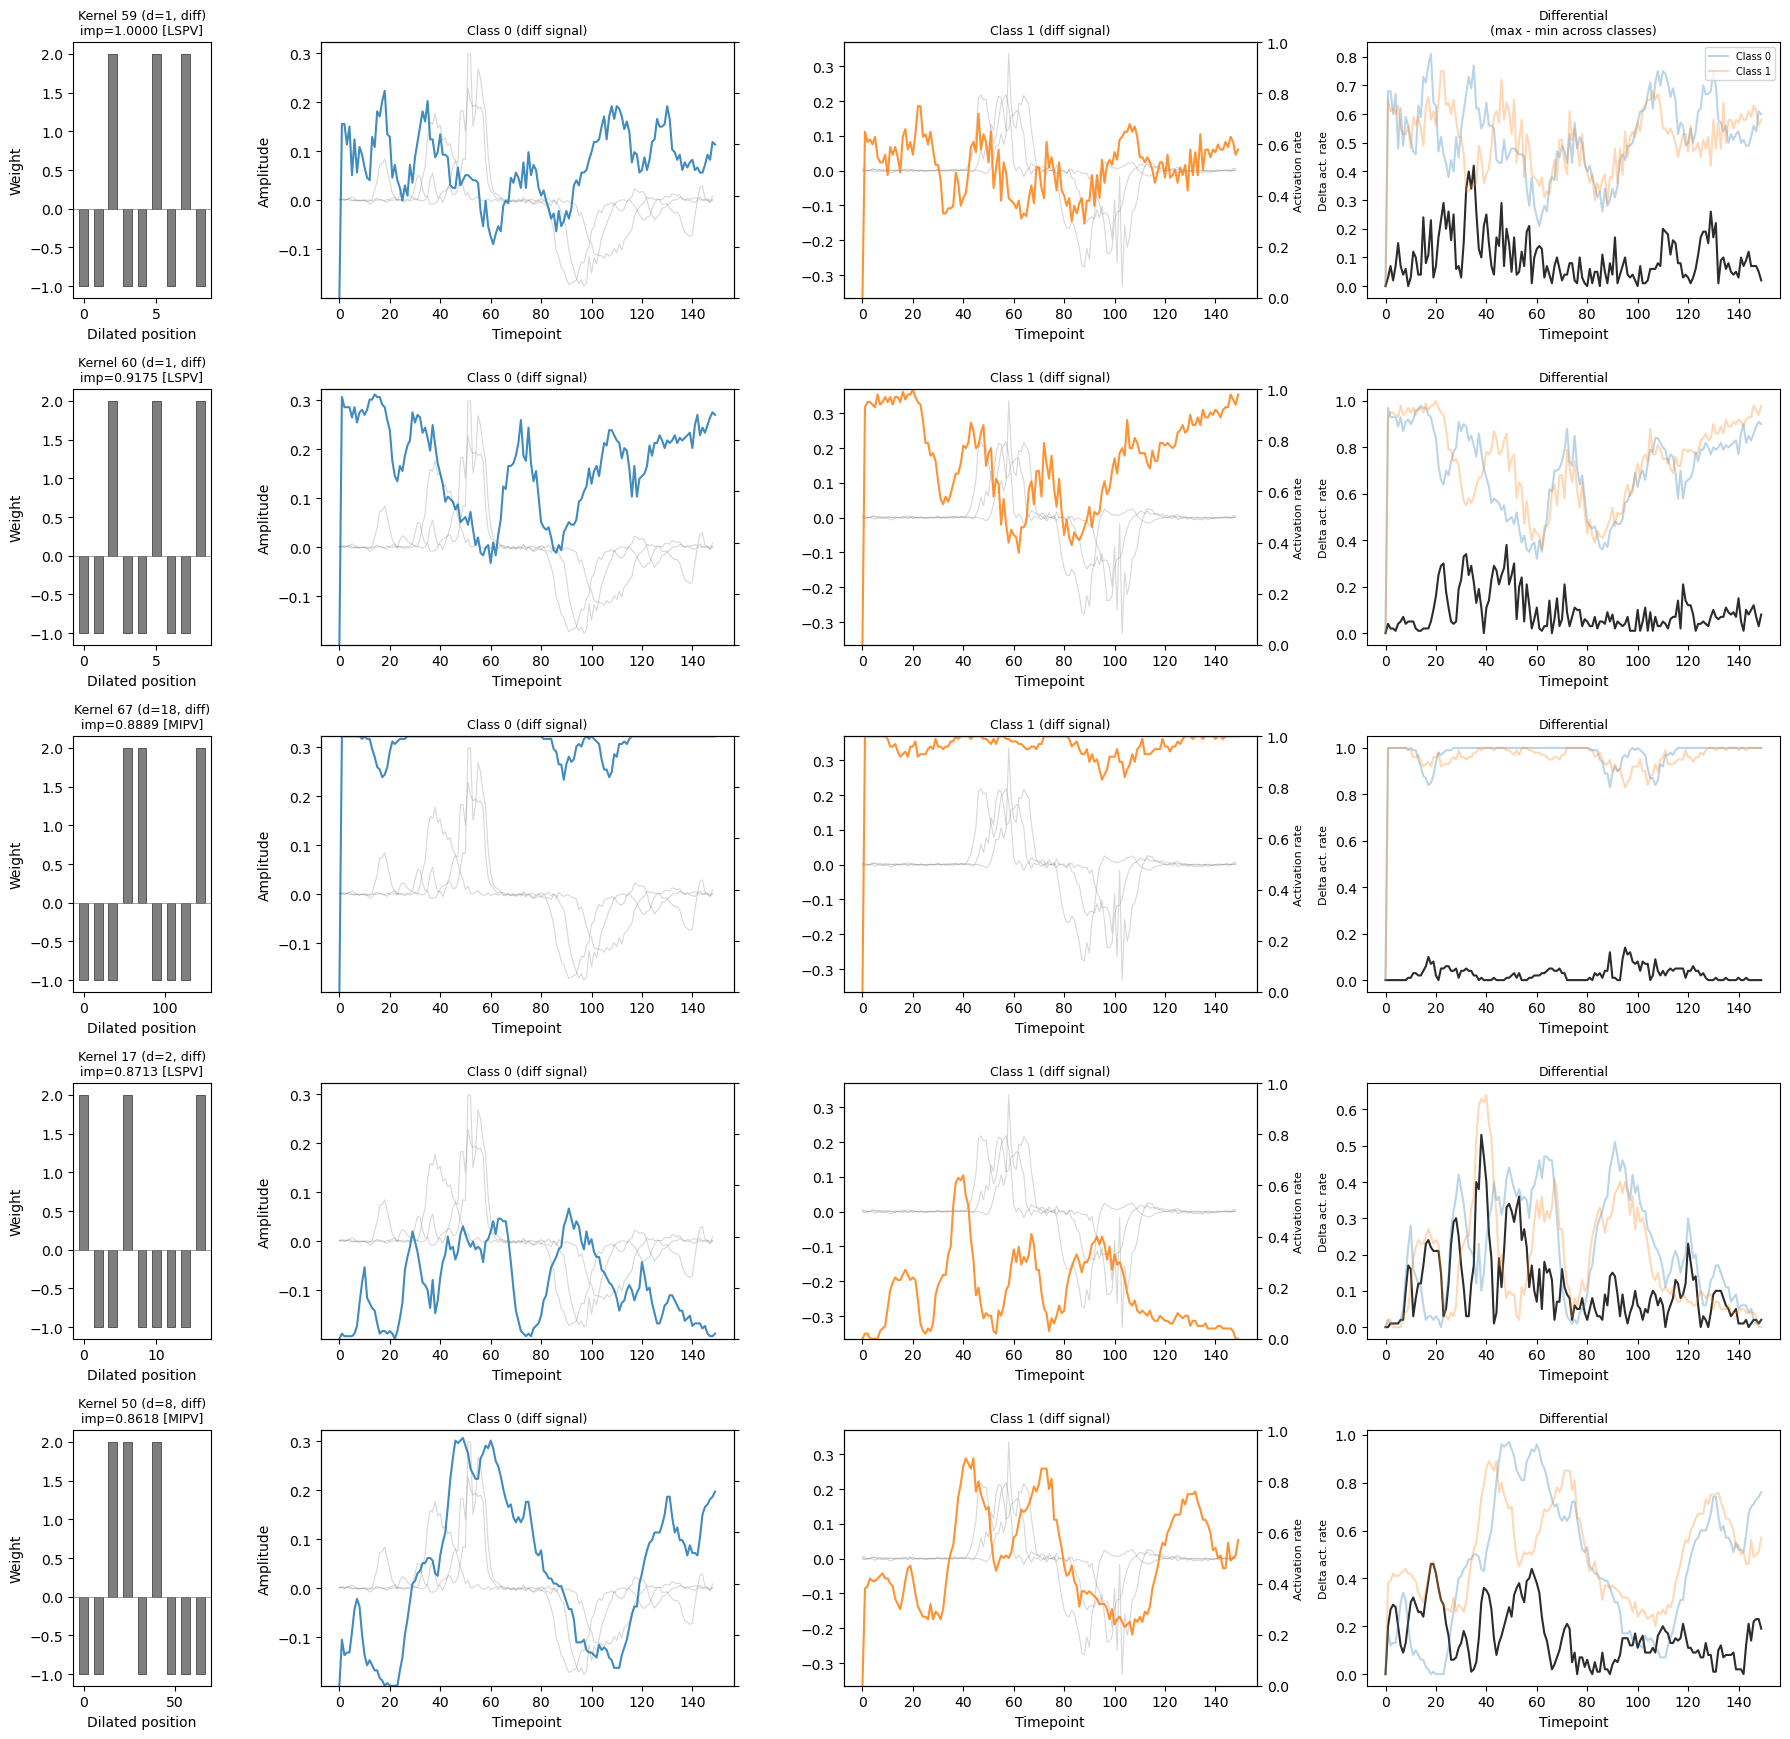

In [6]:
fig = model.plot_top_kernels(X, y, n_kernels=5)

### Temporal importance

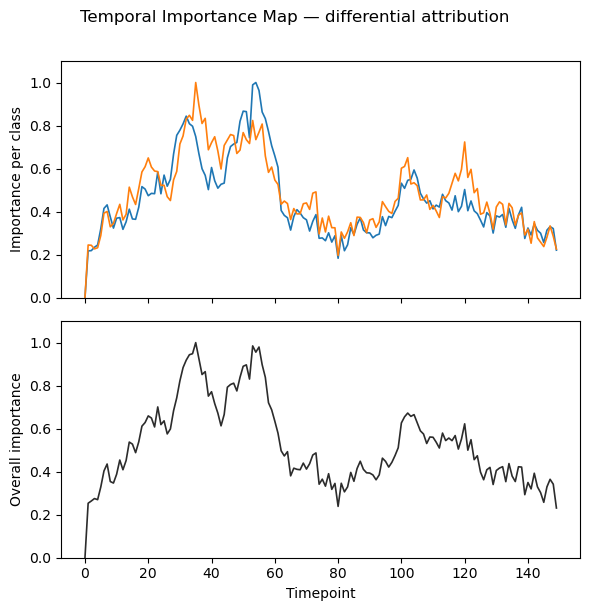

In [7]:
fig = model.plot_temporal_importance(X, y, figsize=(6, 6))

### Feature distributions

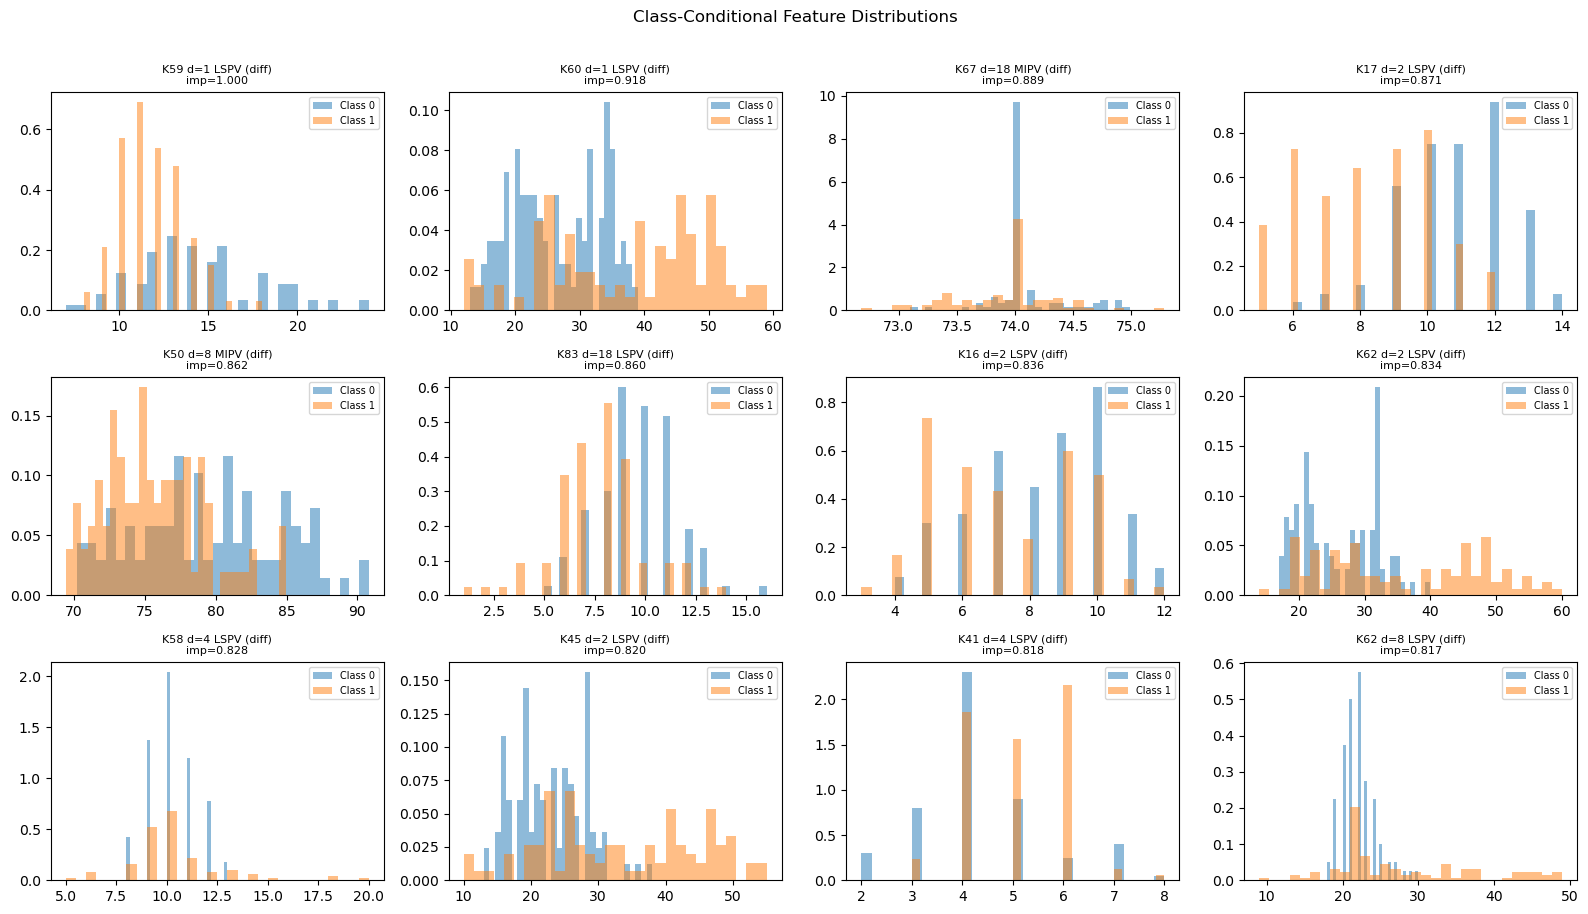

In [8]:
fig = model.plot_feature_distributions(X, y)

### Kernel properties

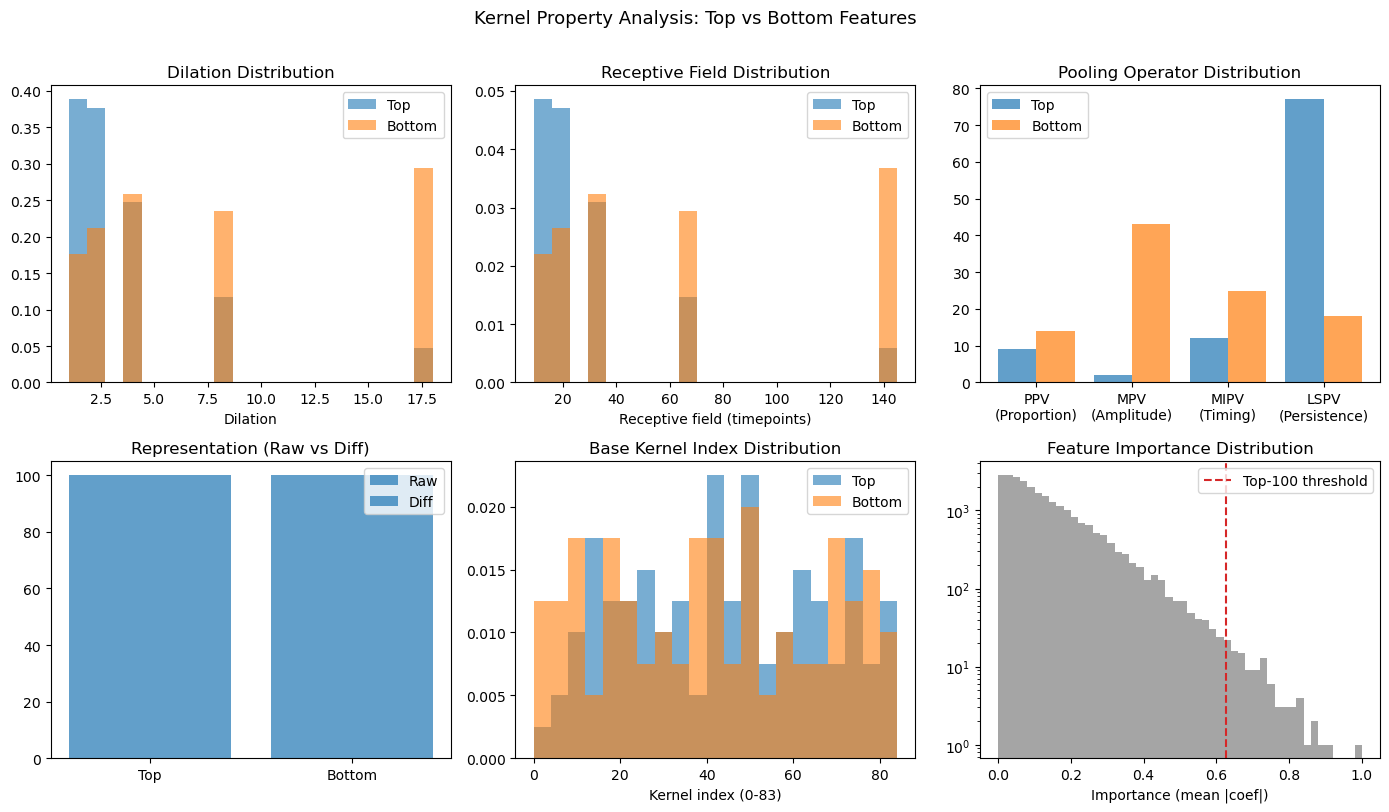

In [9]:
fig = model.plot_kernel_properties()

### Receptive Field Map

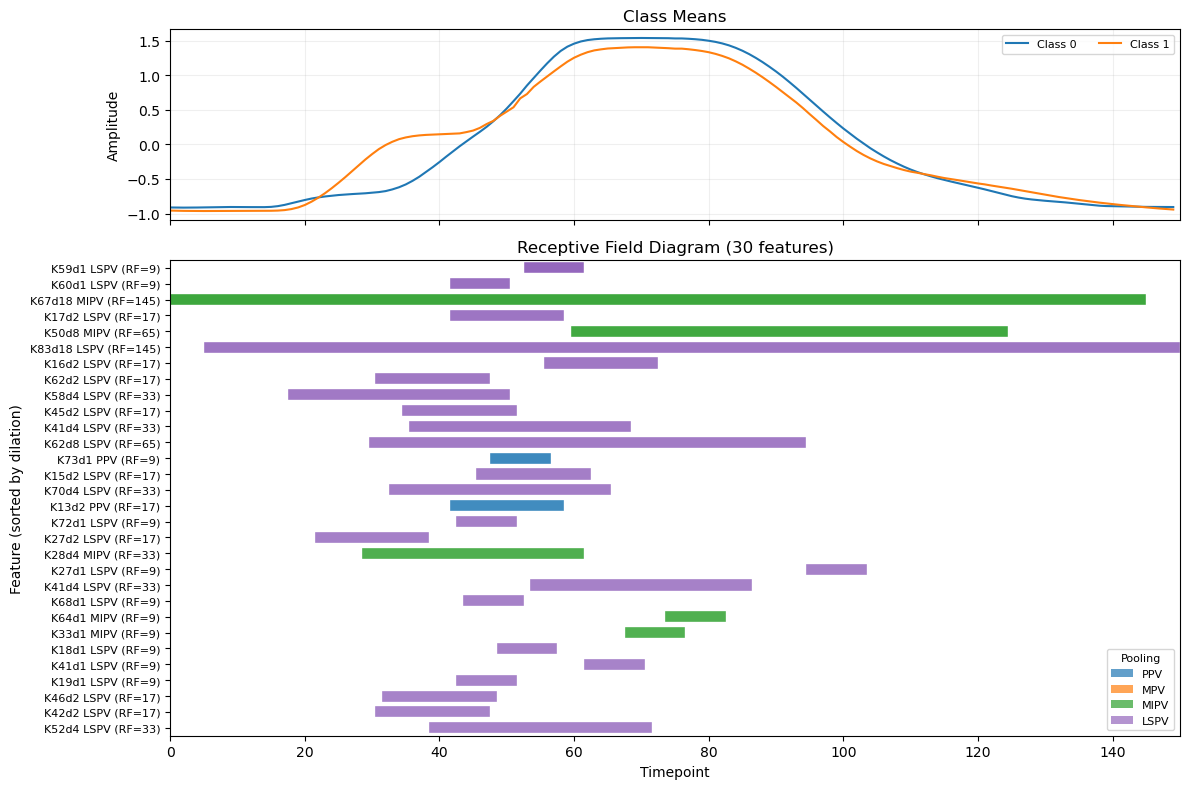

In [10]:
fig = IR.plot_receptive_field_diagram(model, X, y, n_top=30)

## 4. Feature Stability Using Cross-Validation

CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 138 features appeared in every round so far
  Round 2/5: 97 features appeared in every round so far
  Round 3/5: 87 features appeared in every round so far
  Round 4/5: 83 features appeared in every round so far
  Round 5/5: 76 features appeared in every round so far

  Features in ALL folds:  1
  Features in ≥80% folds: 7
  Features in NO folds:   11818
Stable features (≥80% of 25 folds): 7


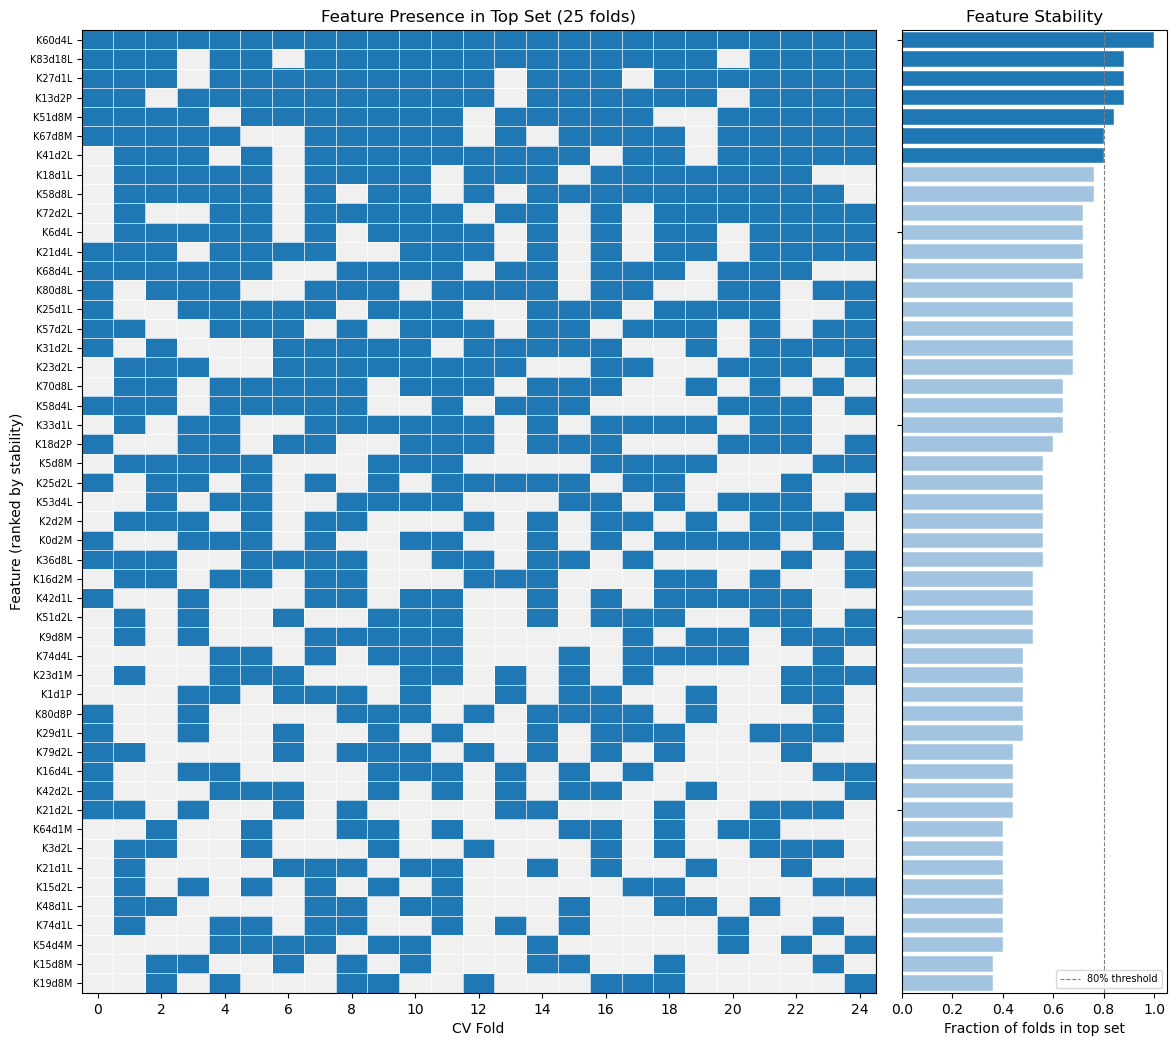

In [11]:
stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
fig = IR.plot_feature_stability(stability, model=model)

# Extract stable features at 80% threshold
stable_features = IR.get_stable_features(stability, threshold=0.8)

### Temporal Importance of Reduced Model

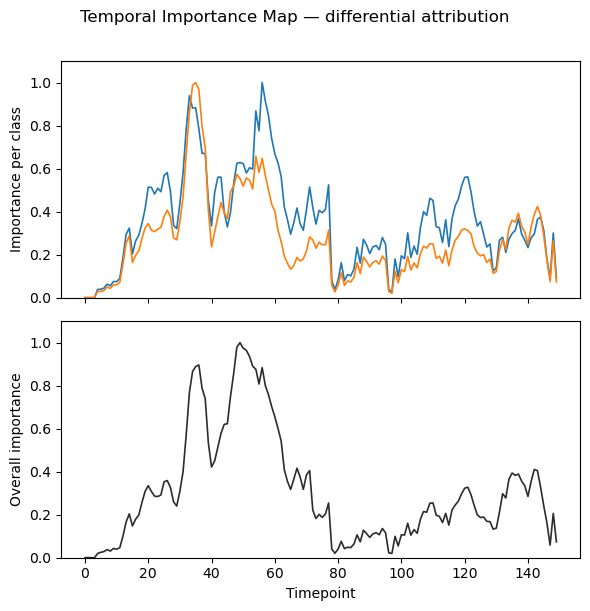

In [12]:
fig, imp_data = model.plot_temporal_importance(
    X, y, n_examples=100,
    feature_mask=stable_features, figsize=(6, 6),
)

### Receptive Fields of Reduced Model

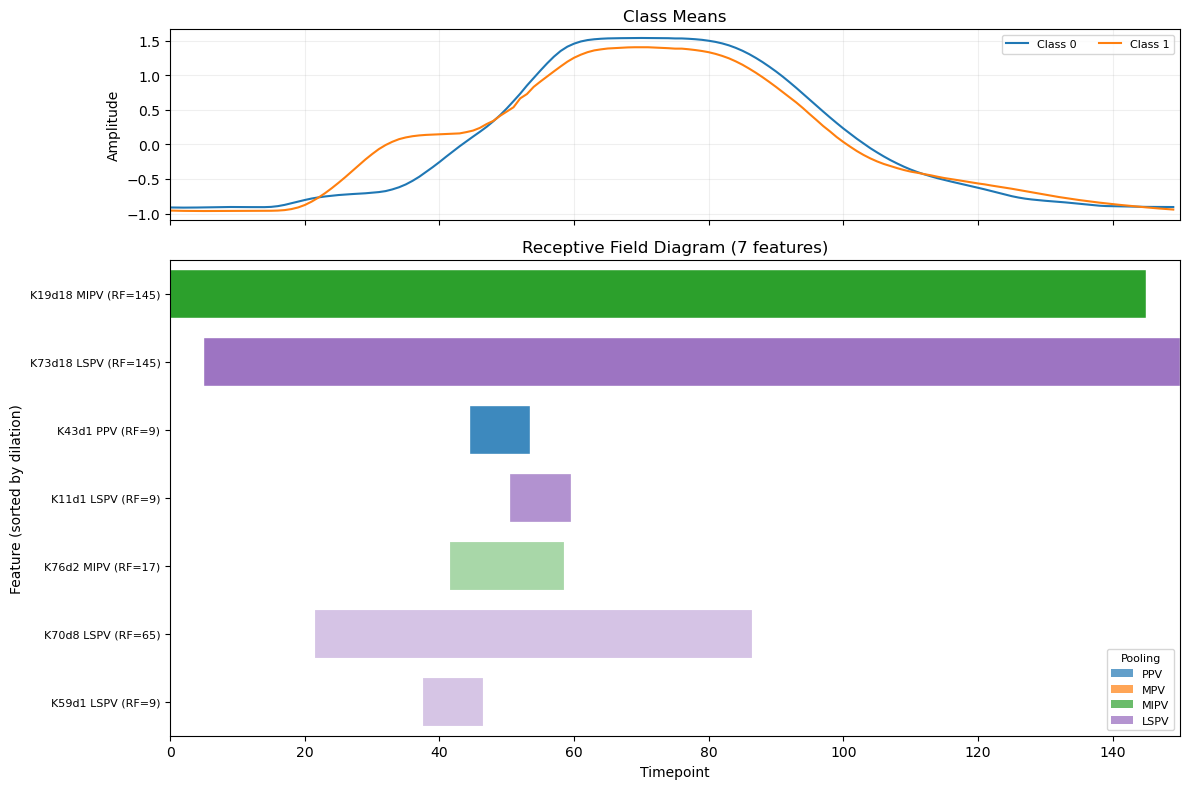

In [13]:
fig = IR.plot_receptive_field_diagram(model, X, y, feature_mask=stable_features, n_top=30)

### Information Decomposition

In [14]:
info = IR.information_decomposition(
    model, X, y,
    group_by='kernel',
    n_shuffles=100,
    feature_mask=stable_features,
)

Information decomposition: 7 features in 7 groups (kernel)
  Ensemble MI: 1.0000 bits
  Group 1/7: I_single=0.0336, I_loo=0.2400
  Group 2/7: I_single=0.0459, I_loo=0.1740
  Group 3/7: I_single=0.0237, I_loo=0.2011
  Group 4/7: I_single=0.0542, I_loo=0.1070
  Group 5/7: I_single=0.0457, I_loo=0.1586
  Group 6/7: I_single=0.0062, I_loo=0.1970
  Group 7/7: I_single=0.0022, I_loo=0.2400
  Computing null distribution (100 shuffles)...

  Results (7 groups):
    Redundant:   0 (0.0%)
    Synergistic: 7 (100.0%)
    Independent: 0 (0.0%)
    Shuffle MI:  0.0354 ± 0.0366
    Ensemble MI: 1.0000
    Sum(I_single): 0.2114
    P_ensemble (I_ens - sum(I_single)): 0.7886


## 5. Class-mean kernel activation analysis

### Activation map of the class means

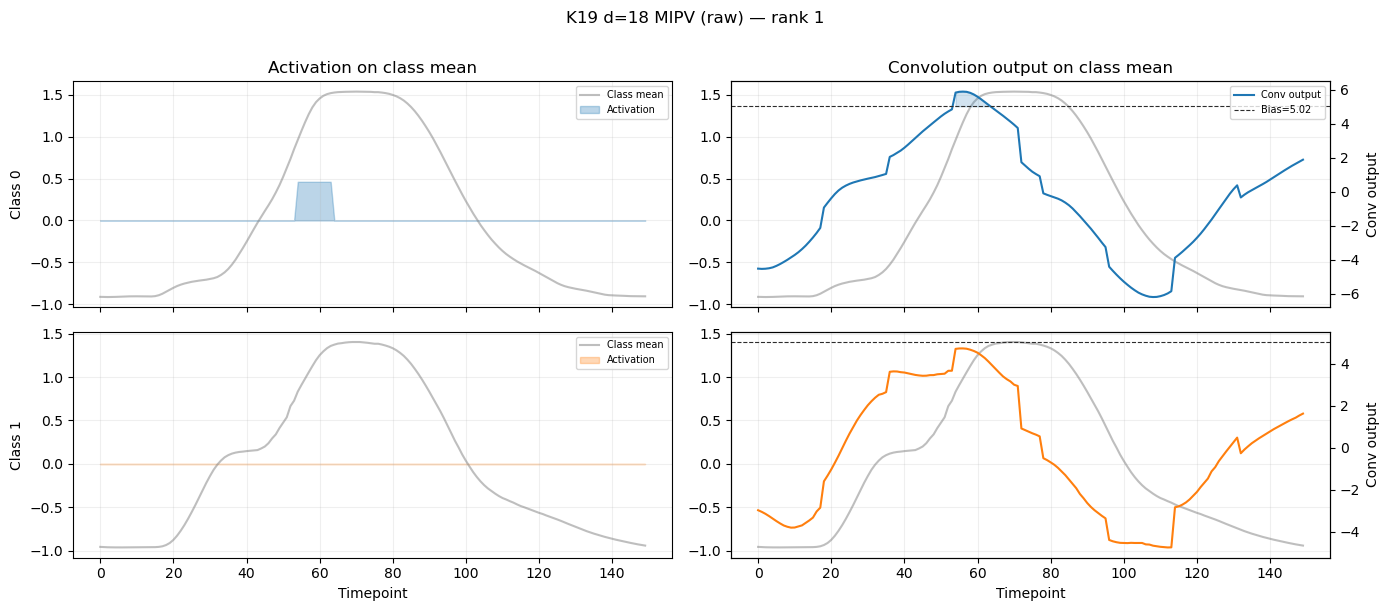

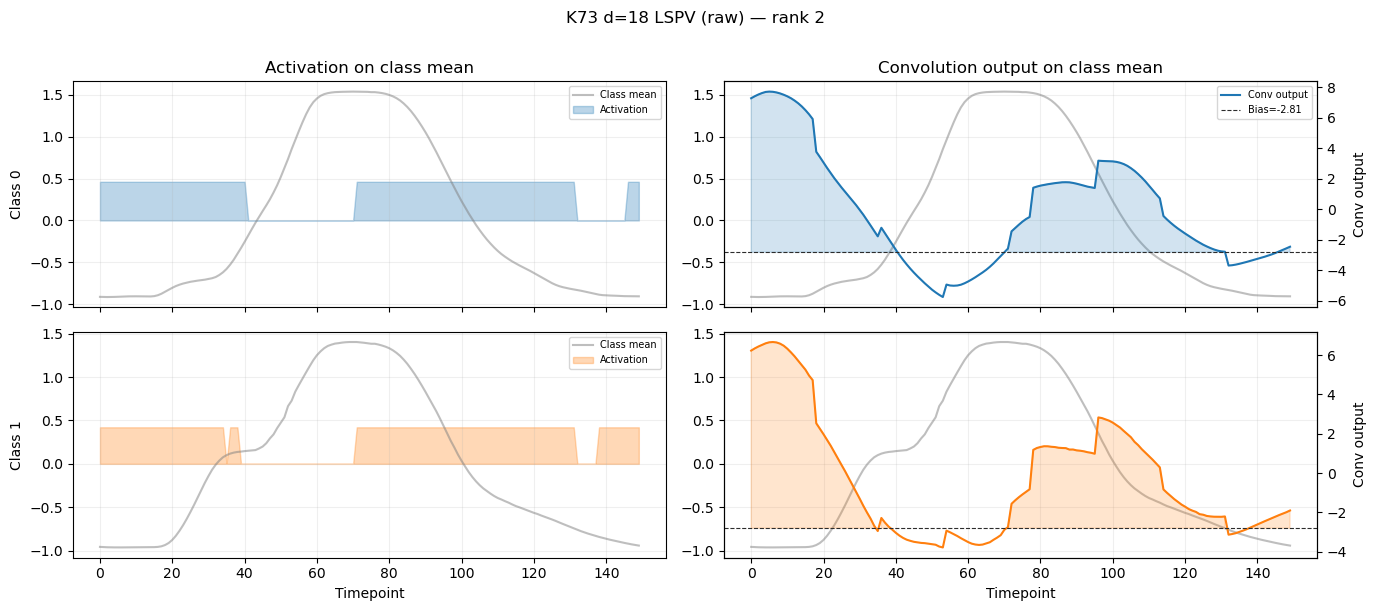

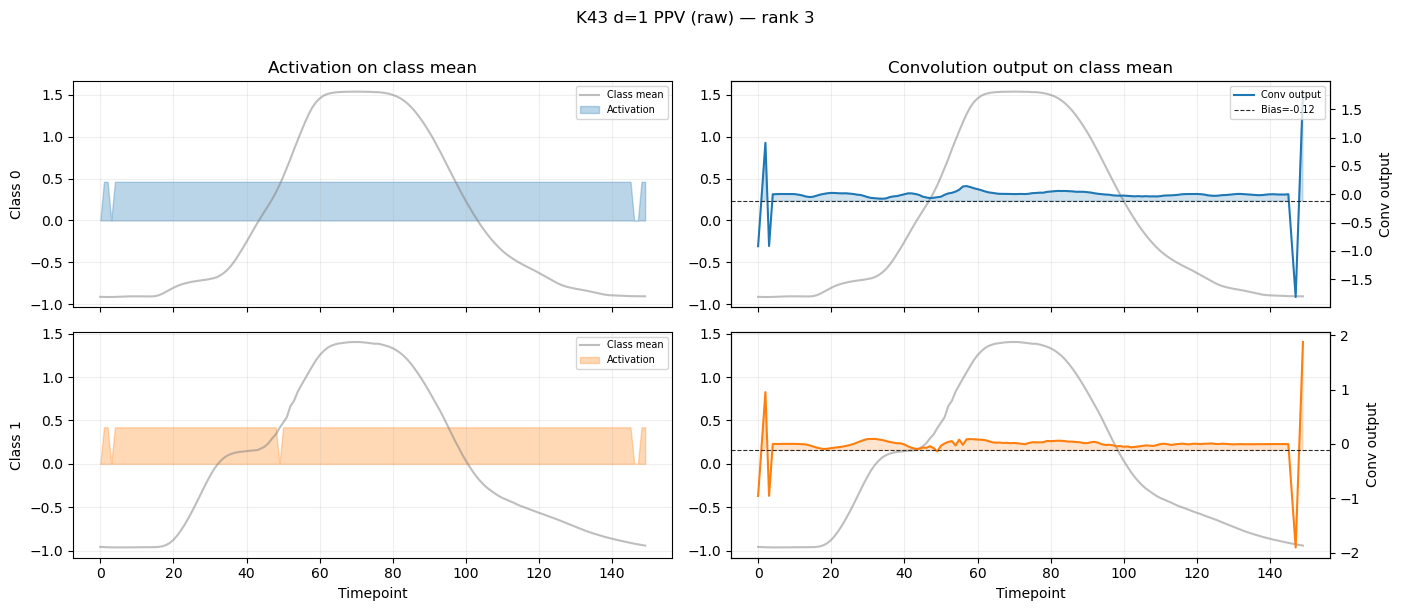

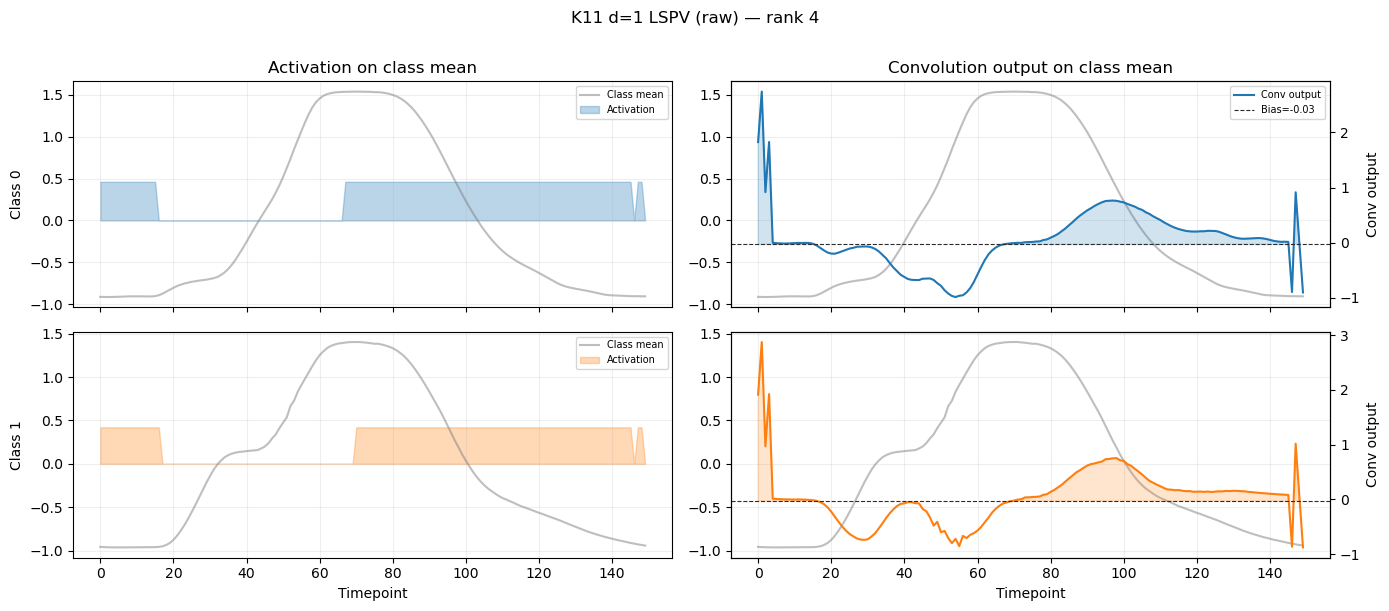

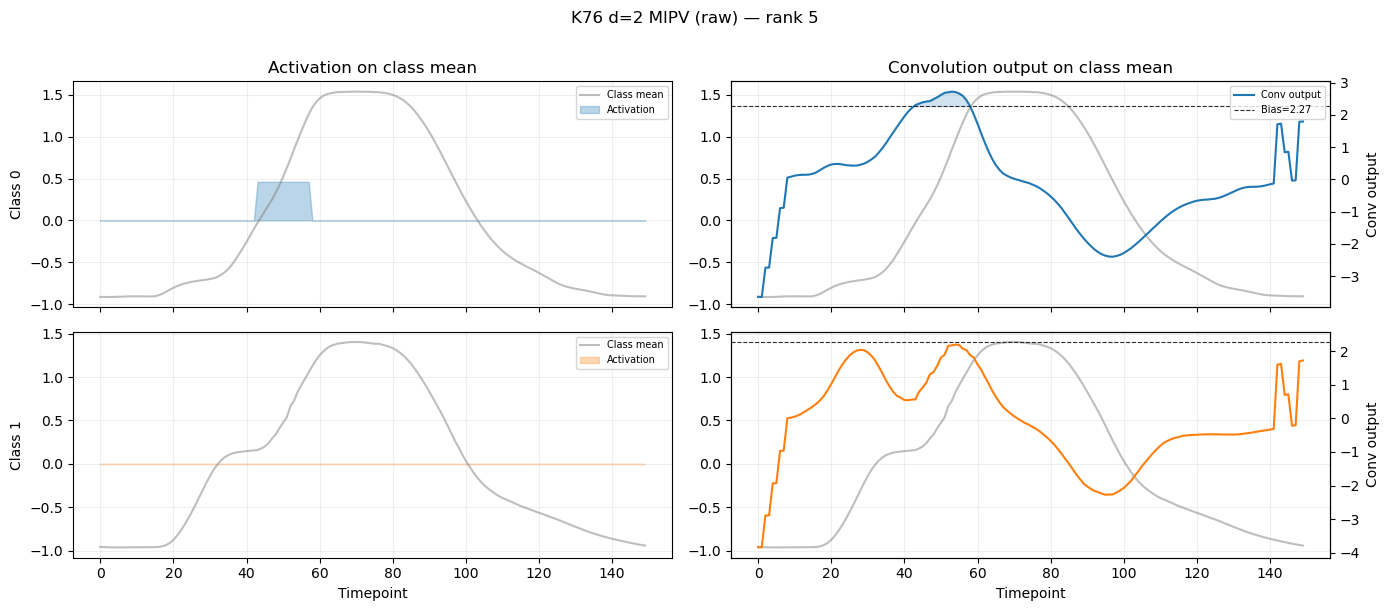

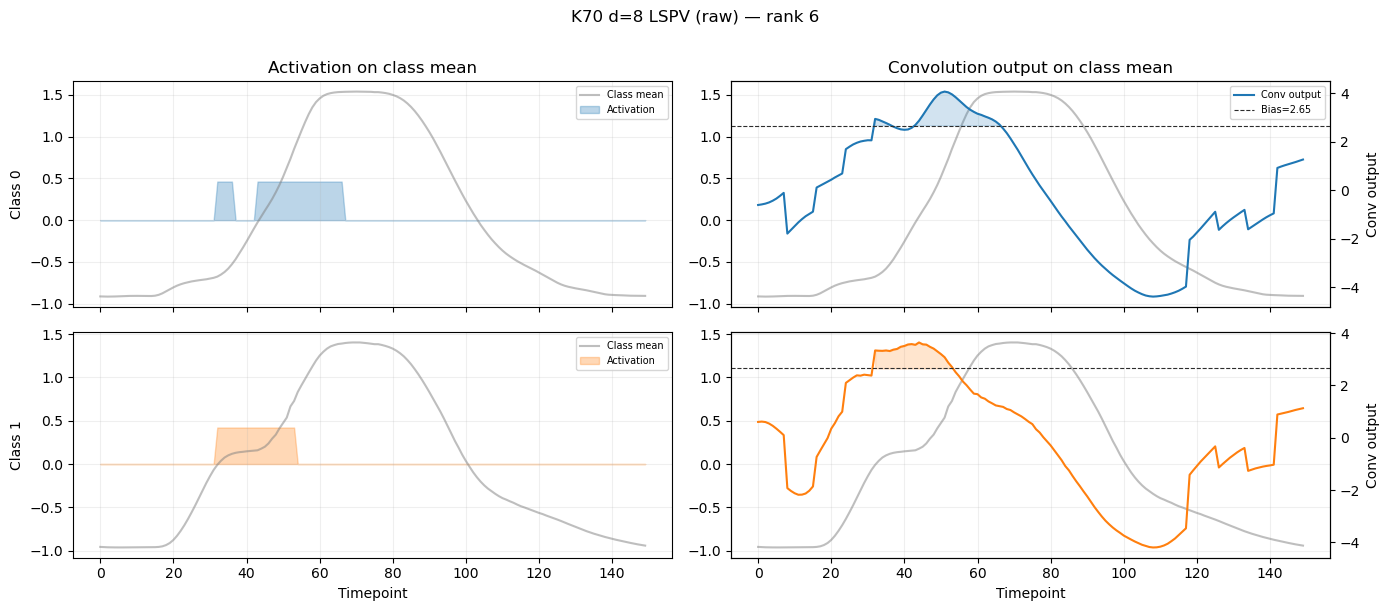

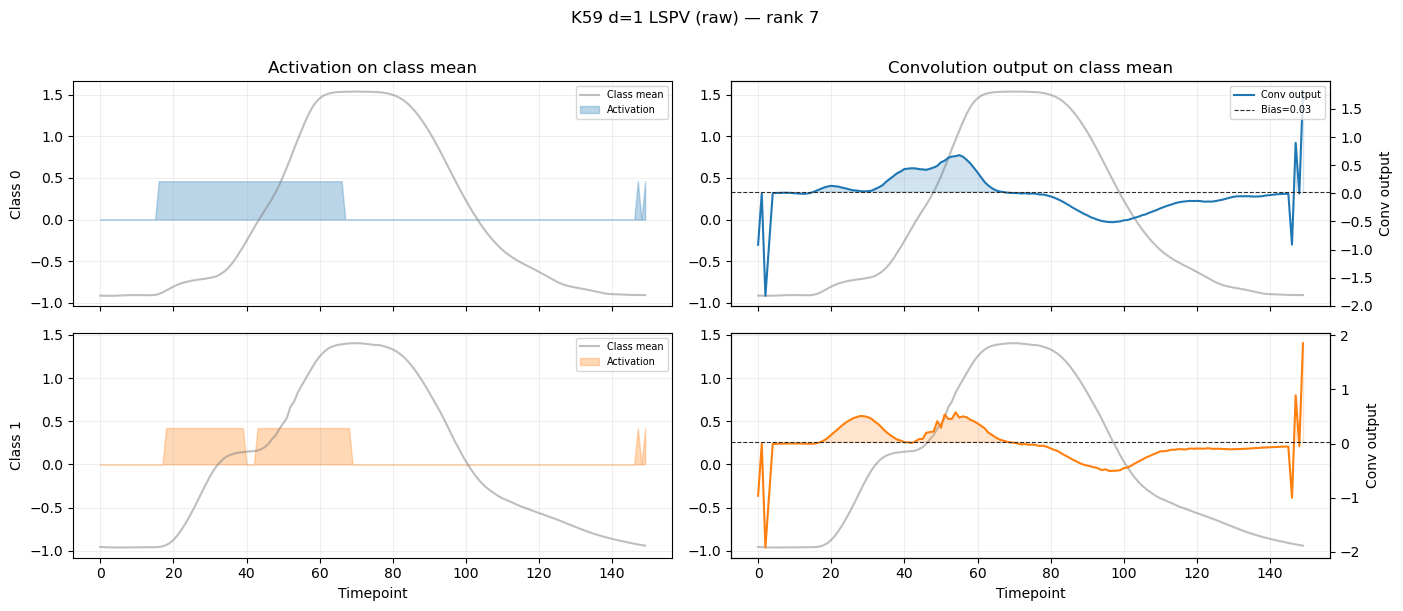

In [15]:
# Top stable features — activation and convolution on class means
top = model.get_top_features(feature_mask=stable_features)
for rank in range(len(top)):
    fig = IR.plot_class_mean_activation(
        model, X, y,
        feature_mask=stable_features,
        feature_rank=rank,
    )
    plt.show()

### Multi-kernel summary on class means

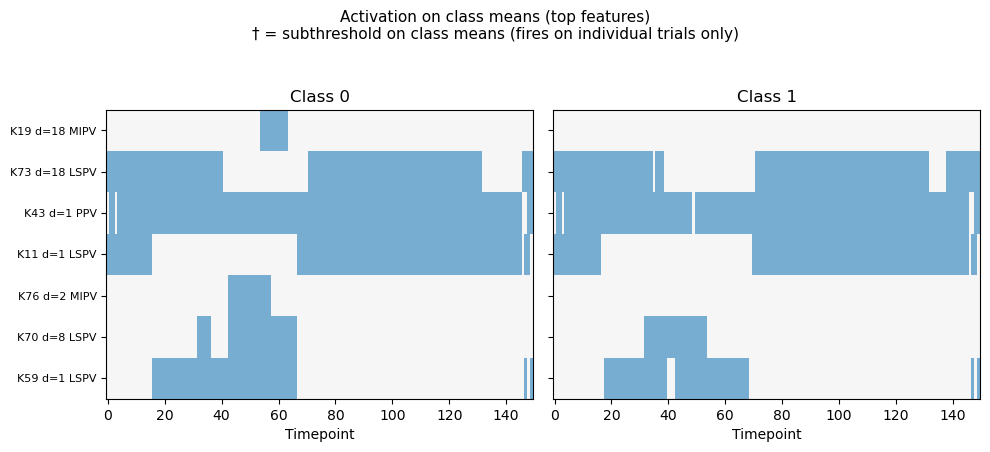

In [16]:
fig = IR.plot_multi_kernel_summary(
    model, X, y,
    feature_mask=stable_features
)

### Activations across all stable kernels for each class mean

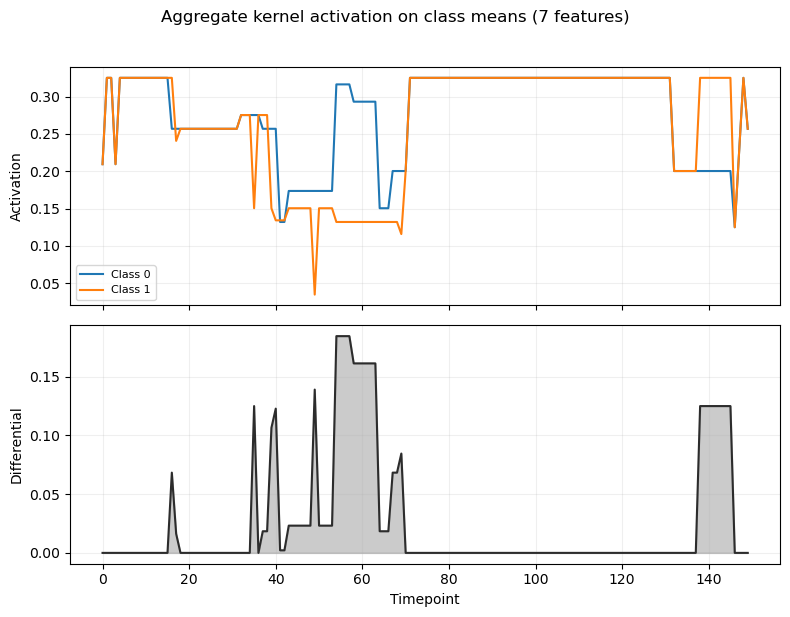

In [17]:
fig, class_act, diff = IR.plot_aggregate_activation(
    model, X, y,
    feature_mask=stable_features,
)